In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [74]:
contigency_table = pd.crosstab(df['sex'], df['survived'])
contigency_table

survived,0,1
sex,,
female,81,233
male,468,109


In [75]:
chi2, p , dof, expected = stats.chi2_contingency(contigency_table)
print("Chi2 value: ", chi2)
print("P value: ", p)
print ("Degrees of freedom: ", dof)
print ("Expected frequencies: \n", expected)


Chi2 value:  260.71702016732104
P value:  1.1973570627755645e-58
Degrees of freedom:  1
Expected frequencies: 
 [[193.47474747 120.52525253]
 [355.52525253 221.47474747]]


In [76]:
# df.head()

In [77]:
# sns.histplot(data= df, x = 'age', hue= 'who', kde=True)

In [78]:
stats.shapiro(df['fare'].dropna().astype(int))
if p > 0.05:
    print("The data is not normally distributed")
else:    print("The data is normally distributed")    

The data is normally distributed


In [79]:
# print (type(statistic))
# print (type(pvalue))

In [80]:
import scipy.stats as stats
# sample data
a = [1, 2, 3, 4, 5]
mu = 3
t_statistic, pvalue = stats.ttest_1samp(a, mu)
print("T-statistic:", t_statistic)
print("P-value:", pvalue)
if pvalue > 0.05:
    print("Fail to reject the null hypothesis")
else:
    print("Reject the null hypothesis")


T-statistic: 0.0
P-value: 1.0
Fail to reject the null hypothesis


In [81]:
import scipy.stats as stats
group1 = [2.3, 3.4, 4.5, 2.3, 3.4]
group2 = [1.2, 2.2, 3.2, 2.2, 2.3]

# perform independent two-sample t-test
t_statistics, p_val = stats.ttest_ind(group1, group2)
print("t-statistic:", t_statistics)
print("p-value:", p_val)
if p_val > 0.05:
    print("Fail to reject the null hypothesis")
else:
    print("Reject the null hypothesis")

t-statistic: 1.8482055087756457
p-value: 0.1017564737182919
Fail to reject the null hypothesis


In [82]:
import scipy.stats as stats
group1 = [2.3, 3.4, 4.5, 2.3, 3.4]
group2 = [1.2, 2.2, 3.2, 2.2, 2.3]

# perform dependent two-sample t-test
t_stat, p_val = stats.ttest_rel(group1, group2)
print("t-statistic:", t_stat)
print("p-value:", p_val)
if p_val > 0.05:
    print("Fail to reject the null hypothesis")
else:
    print("Reject the null hypothesis")

t-statistic: 4.400152785735412
p-value: 0.011689796927234283
Reject the null hypothesis


In [83]:
import scipy.stats as stats
group1 = [2.3, 3.4, 4.5, 2.3, 3.4]
group2 = [1.2, 2.2, 3.2, 2.2, 2.3]

# perform Levene's test for equality of variances
w_stat, p_val = stats.levene(group1, group2)
print("Levene's statistic:", w_stat)
print("p-value:", p_val)
if p_val > 0.05:
    print("Fail to reject the null hypothesis")
else:
    print("Reject the null hypothesis")

Levene's statistic: 0.44651162790697696
p-value: 0.5228039334796072
Fail to reject the null hypothesis


In [84]:
import scipy.stats as stats
group1 = [2.3, 3.4, 4.5, 2.3, 3.4]
group2 = [1.2, 2.2, 3.2, 2.2, 2.3]

# perform Bartlett's test for equality of variances
w_stat, p_val = stats.bartlett(group1, group2)
print("Bartlett's statistic:", w_stat)
print("p-value:", p_val)
if p_val > 0.05:
    print("Fail to reject the null hypothesis")
else:
    print("Reject the null hypothesis")

Bartlett's statistic: 0.24050679805097827
p-value: 0.6238403179343277
Fail to reject the null hypothesis


In [85]:
import scipy.stats as stats
a = [2.3, 3.4, 4.5, 2.3, 3.4]
b = [11.2, 12.2, 13.2, 12.2, 12.3]
c_group = [22.3, 23.4, 24.5, 22.3, 23.4]
# perform one-way ANOVA
f_stat, p_val = stats.f_oneway(a, b, c_group)
# print the results base on if else conditions
if p_val> 0.05:
    print(f'p-value: {p_val}, Means are equal (fail to reject H0)')
else:
    print(f'p-value: {p_val}, Means are not equal (reject H0)')

p-value: 4.279979561060642e-13, Means are not equal (reject H0)


In [86]:
df = pd.DataFrame({
    'fertilizer': ['fertilizer1'] * len(a) + ['fertilizer2'] * len(b) + ['fertilizer3'] * len(c_group),
    'growth': a + b + c_group
})
df.head()

,fertilizer,growth
0,fertilizer1,2.3
1,fertilizer1,3.4
2,fertilizer1,4.5
3,fertilizer1,2.3
4,fertilizer1,3.4


In [87]:
# fit the model
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('growth ~ (fertilizer)', data=df).fit()

In [88]:
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)
if anova_table["PR(>F)"].iloc[0] < 0.05:
    print("Reject the null hypothesis: There is a significant difference between the groups.")
else: 
    print("Fail to reject the null hypothesis: There is no significant difference between the groups.")

              sum_sq    df          F        PR(>F)
fertilizer  1003.072   2.0  685.15847  4.279980e-13
Residual       8.784  12.0        NaN           NaN
Reject the null hypothesis: There is a significant difference between the groups.


In [89]:
data = pd.DataFrame({
    "Growth": [20, 22, 19, 24, 25, 28, 30, 27, 26, 29, 18, 20, 22, 19, 24,
               21, 23, 20, 25, 26, 29, 31, 28, 27, 30, 19, 21, 23, 20, 25],
    "Fertilizer": ["F1", "F1", "F1", "F1", "F1", "F2", "F2", "F2", "F2", "F2",
                   "F3", "F3", "F3", "F3", "F3", "F1", "F1", "F1", "F1", "F1",
                   "F2", "F2", "F2", "F2", "F2", "F3", "F3", "F3", "F3", "F3"],
    "Sunlight": ["High"] * 15 + ["Low"] * 15
})

In [90]:
data.sample(5)

,Growth,Fertilizer,Sunlight
18,25,F1,Low
2,19,F1,High
8,26,F2,High
11,20,F3,High
17,20,F1,Low


In [91]:
from statsmodels.formula.api import ols
from statsmodels.formula.api import ols
# from statsmodels.formula.api import C 

model = ols('Growth~ Fertilizer + Sunlight + Fertilizer:Sunlight', data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
Fertilizer,3.090667e+02,2.0,3.132432e+01,2.038888e-07
Sunlight,7.500000e+00,1.0,1.520270e+00,2.295198e-01
Fertilizer:Sunlight,6.441240e-28,2.0,6.528284e-29,1.000000e+00
Residual,1.184000e+02,24.0,NaN,NaN


In [92]:
anova_table

,sum_sq,df,F,PR(>F)
Fertilizer,3.090667e+02,2.0,3.132432e+01,2.038888e-07
Sunlight,7.500000e+00,1.0,1.520270e+00,2.295198e-01
Fertilizer:Sunlight,6.441240e-28,2.0,6.528284e-29,1.000000e+00
Residual,1.184000e+02,24.0,NaN,NaN


In [93]:
data = pd.DataFrame({
    "Growth": [20, 22, 19, 24, 25, 28, 30, 27, 26, 29, 18, 20, 22, 19, 24,
               21, 23, 20, 25, 26, 29, 31, 28, 27, 30, 19, 21, 23, 20, 25,
               20, 22, 21, 23, 24, 26, 28, 25, 27, 29, 17, 19, 21, 18, 20],
    "Fertilizer": ["F1", "F1", "F1", "F1", "F1", "F2", "F2", "F2", "F2", "F2",
                   "F3", "F3", "F3", "F3", "F3", "F1", "F1", "F1", "F1", "F1",
                   "F2", "F2", "F2", "F2", "F2", "F3", "F3", "F3", "F3", "F3",
                   "F1", "F1", "F1", "F1", "F1", "F2", "F2", "F2", "F2", "F2",
                   "F3", "F3", "F3", "F3", "F3"],
    "Sunlight": ["High"] * 15 + ["Low"] * 15 + ["High"] * 15,
    "Watering": ["Regular"] * 15 + ["Sparse"] * 15 + ["Regular"] * 15
})

In [94]:
model = ols('Growth ~ Fertilizer + Sunlight + Watering + Fertilizer:Sunlight + Fertilizer:Watering + Sunlight:Watering + Fertilizer:Sunlight:Watering', data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
Fertilizer,4.680444e+02,2.0,5.802204e+01,2.050614e-12
Sunlight,-2.880691e-13,1.0,-7.142209e-14,1.000000e+00
Watering,7.330417e-13,1.0,1.817459e-13,9.999997e-01
Fertilizer:Sunlight,7.222841e-13,2.0,8.953936e-14,1.000000e+00
Fertilizer:Watering,4.426063e-13,2.0,5.486855e-14,1.000000e+00
Sunlight:Watering,2.054444e+01,1.0,5.093664e+00,2.969139e-02
Fertilizer:Sunlight:Watering,1.088889e+00,2.0,1.349862e-01,8.741344e-01
Residual,1.573000e+02,39.0,NaN,NaN


In [95]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np
# take the values for fertilizer1, fertilizer2, and fertilizer3
fertilizer1 = np.array([12, 13, 14, 15, 16, 14, 13, 15, 14, 16, 15, 13, 14, 12, 13, 15, 16, 14, 13, 15, 14])
fertilizer2 = np.array([13, 14, 15, 16, 17, 15, 14, 16, 15, 17, 16, 14, 15, 13, 14, 16, 17, 15, 14, 16, 15])
fertilizer3 = np.array([20, 21, 22, 23, 24, 22, 21, 23, 22, 24, 23, 21, 22, 20, 21, 23, 24, 22, 21, 23, 22])
data = {
'Growth': np.concatenate([fertilizer1, fertilizer2, fertilizer3]),
'Fertilizer': ['F1']*len (fertilizer1) + ['F2']*len(fertilizer2) + ['F3']*len(fertilizer3)
}
tukey = pairwise_tukeyhsd(endog=data['Growth'], groups= data['Fertilizer'], alpha= 0.05)
print (tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
    F1     F2      1.0 0.0271 0.0946 1.9054   True
    F1     F3      8.0    0.0 7.0946 8.9054   True
    F2     F3      7.0    0.0 6.0946 7.9054   True
--------------------------------------------------


In [96]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [97]:
data = pd.DataFrame({
"Growth": [20, 22, 19, 24, 25, 28, 30, 27, 26, 29, 18, 20, 22, 19, 24,
21, 23, 20, 25, 26, 29, 31, 28, 27, 30, 19, 21, 23, 20, 25],
"Fertilizer": ["F1", "F1", "F1", "F1", "F1", "F2", "F2", "F2", "F2", "F2",
"F3", "F3", "F3", "F3", "F3", "F1", "F1", "F1", "F1", "F1",
"F2", "F2", "F2", "F2", "F2", "F3", "F3", "F3", "F3", "F3"],
"Sunlight": ["High"] * 15 + ["Low"] * 15 , 
"Watering": ["Regular"] * 15 + ["Sparse"] * 15
})
tukey = pairwise_tukeyhsd(data['Growth'] , data['Sunlight'] + data['Fertilizer'] + data['Watering'], alpha=0.05)
print (tukey)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------
HighF1Regular HighF2Regular      6.0 0.0032   1.6566 10.3434   True
HighF1Regular HighF3Regular     -1.4 0.9145  -5.7434  2.9434  False
HighF1Regular   LowF1Sparse      1.0 0.9786  -3.3434  5.3434  False
HighF1Regular   LowF2Sparse      7.0 0.0006   2.6566 11.3434   True
HighF1Regular   LowF3Sparse     -0.4 0.9997  -4.7434  3.9434  False
HighF2Regular HighF3Regular     -7.4 0.0003 -11.7434 -3.0566   True
HighF2Regular   LowF1Sparse     -5.0 0.0176  -9.3434 -0.6566   True
HighF2Regular   LowF2Sparse      1.0 0.9786  -3.3434  5.3434  False
HighF2Regular   LowF3Sparse     -6.4 0.0016 -10.7434 -2.0566   True
HighF3Regular   LowF1Sparse      2.4 0.5396  -1.9434  6.7434  False
HighF3Regular   LowF2Sparse      8.4    0.0   4.0566 12.7434   True
HighF3Regular   LowF3Sparse      1.0 0.9786  -3.

In [98]:
import scipy.stats as stats
import pandas as pd
# Sample data
fertilizer1 = [20, 22, 19, 24, 25]
fertilizer2 = [28, 30, 27, 26, 29]
fertilizer3 = [18, 20, 22, 19, 24]
data = {
'Growth': fertilizer1 + fertilizer2 + fertilizer3,
'Fertilizer': ['F1']*len(fertilizer1) + ['F2']*len(fertilizer2) + ['F3']*len(fertilizer3)
}
df = pd.DataFrame(data)
num_comparisons = 3
alpha = 0.05
adjusted_alpha = alpha / num_comparisons
tukey = pairwise_tukeyhsd(endog=df['Growth'], groups=df['Fertilizer'], alpha=adjusted_alpha)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.02 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
    F1     F2      6.0 0.0029   1.3874 10.6126   True
    F1     F3     -1.4 0.5928  -6.0126  3.2126  False
    F2     F3     -7.4 0.0005 -12.0126 -2.7874   True
-----------------------------------------------------


In [99]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.multivariate.manova import MANOVA
# Example dataset
data = {
'Method': ['A', 'A', 'A', 'B', 'B', 'B', 'C', 'C', 'C'],
'MathScore': [20, 22, 21, 19, 18, 20, 22, 23, 21],
'ScienceScore': [30, 28, 29, 33, 32, 31, 29, 27, 28]
}
df = pd.DataFrame(data)
manova = MANOVA.from_formula('MathScore + ScienceScore ~ Method', data=df)
result = manova.mv_test()
print(result)

                   Multivariate linear model
                                                                
----------------------------------------------------------------
       Intercept          Value   Num DF Den DF  F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda    0.0005 2.0000 5.0000 4711.5000 0.0000
         Pillai's trace    0.9995 2.0000 5.0000 4711.5000 0.0000
 Hotelling-Lawley trace 1884.6000 2.0000 5.0000 4711.5000 0.0000
    Roy's greatest root 1884.6000 2.0000 5.0000 4711.5000 0.0000
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
             Method         Value  Num DF  Den DF F Value Pr > F
----------------------------------------------------------------
              Wilks' lambda 0.1802 4.0000 10.0000  3.3896 0.0534
             Pillai's trace 0.8468 4.0000 12.

In [100]:
#
import pandas as pd
import numpy as np
def pearson(x, y):
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_std = np.std(x)
    y_std = np.std(y)
    n = len(x)
    return sum((x-x_mean)*(y-y_mean))/(n*x_std*y_std)
# example dataset
x = np.array([1,2,3,4,5])
y = np.array([2,4,5,4,5])
print(f"Pearson Correlation Coefficient: {pearson(x,y)}")
if pearson(x,y) < 0.6 and pearson(x,y) > 0:
    print("Positive Correlation.")
elif pearson(x,y) > 0.6:
    print("Highly Positive Correlation.")
elif pearson(x,y) > -0.6 and pearson(x,y)< 0:
    print("Negative Correlation.")
elif pearson(x,y) < -0.6:
    print("Highly Negative Correlation.")
else:
    print("No Correlation.")

Pearson Correlation Coefficient: 0.7745966692414834
Highly Positive Correlation.


In [101]:
import pandas as pd
import numpy as np
# example dataset
x = np.array([1,2,3,4,5])
y = np.array([2,4,5,4,5])
# pearson's correlation coefficient
pearson = np.corrcoef(x,y)
print(f"Pearson Correlation Coefficient: {pearson[0,1]}")

Pearson Correlation Coefficient: 0.7745966692414834


In [102]:
x = pd.Series([1,2,3,4,5])
y = pd.Series([2,4,5,4,5])
spearman = x.corr(y)
print(f"Spearman Correlation Coefficient: {spearman}")


Spearman Correlation Coefficient: 0.7745966692414834


In [103]:
df = pd.DataFrame({'x': x , 'y': y})
df.head()

,x,y
0,1,2
1,2,4
2,3,5
3,4,4
4,5,5


In [104]:
df = pd.DataFrame({'x': x , 'y': y})
pearson_corr = df.corr(method='pearson')
spearman_corr = df.corr(method = 'spearman')
kendall_corr = df.corr(method = 'kendall')
print(f"Pearson Correlation Coefficient: {pearson_corr}")
print(f"Spearman Correlation Coefficient: {spearman_corr}")
print(f"Kendall Correlation Coefficient: {kendall_corr}")

Pearson Correlation Coefficient:           x         y
x  1.000000  0.774597
y  0.774597  1.000000
Spearman Correlation Coefficient:           x         y
x  1.000000  0.737865
y  0.737865  1.000000
Kendall Correlation Coefficient:          x        y
x  1.00000  0.67082
y  0.67082  1.00000


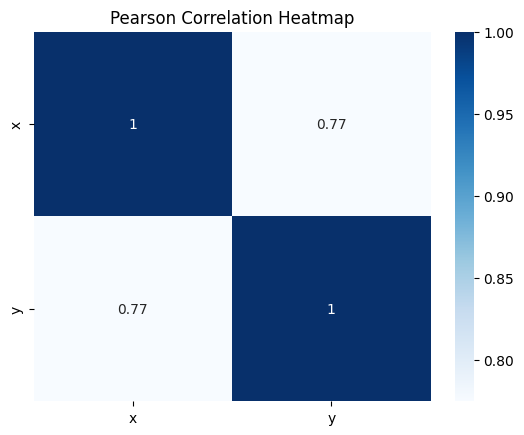

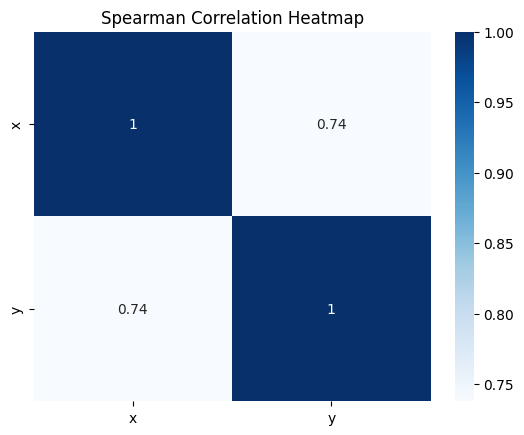

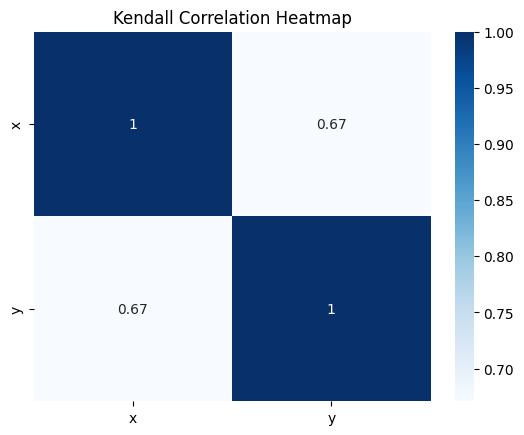

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.corr(method='pearson'), annot=True, cmap='Blues')
plt.title('Pearson Correlation Heatmap')
plt.show()
sns.heatmap(df.corr(method='spearman'), annot=True, cmap='Blues')
plt.title('Spearman Correlation Heatmap')
plt.show()
sns.heatmap(df.corr(method='kendall'), annot=True, cmap='Blues')
plt.title('Kendall Correlation Heatmap')
plt.show()

In [106]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.multivariate.manova import MANOVA
import scipy.stats as stats


In [107]:
from scipy.stats import chisquare
obs_f = np.array([30, 50])
total_meals = obs_f.sum()
expected_f = np.array([total_meals/2, total_meals/2])
chi2_statistic, p_value = chisquare(obs_f, f_exp=expected_f)
print("Chi2 value: ", chi2_statistic)
print("P value: ", p_value)
if p_value > 0.05:
    print("Fail to reject the null hypothesis")
else:
    print("Reject the null hypothesis")  

Chi2 value:  5.0
P value:  0.025347318677468325
Reject the null hypothesis


In [108]:
df = sns.load_dataset('tips')
contigency_table = pd.crosstab(df['sex'], df['day'])
print (contigency_table)

day     Thur  Fri  Sat  Sun
sex                        
Male      30   10   59   58
Female    32    9   28   18


In [109]:
df = sns.load_dataset('tips')
contigency_table = pd.crosstab(df['sex'], df['smoker'])
chi2, p , dof, expected = stats.chi2_contingency(contigency_table)
print("Chi2 value: ", chi2)
print("P value: ", p)
print ("Degrees of freedom: ", dof)
print ("Expected frequencies: \n", expected)
if p > 0.05:
    print("Fail to reject the null hypothesis")
else:
    print("Reject the null hypothesis")


Chi2 value:  0.0
P value:  1.0
Degrees of freedom:  1
Expected frequencies: 
 [[59.84016393 97.15983607]
 [33.15983607 53.84016393]]
Fail to reject the null hypothesis


In [110]:
df = sns.load_dataset('titanic')
df['fare'] = df['fare'].fillna(df['fare'].median())
df['age'] = df['age'].fillna(df['age'].median())

In [111]:
from scipy import stats

stat, p = stats.shapiro(df['fare'].dropna())

print("Shapiro Statistic:", stat)
print("P-value:", p)

if p > 0.05:
    print("Fail to reject H0: Data is normally distributed")
else:
    print("Reject H0: Data is NOT normally distributed")

Shapiro Statistic: 0.5218913010396559
P-value: 1.0840444395829658e-43
Reject H0: Data is NOT normally distributed


In [112]:
statistics , p = stats.ttest_1samp(df['age'].dropna().astype(int), 29)
print("T-Test Statistic: ", statistics)
print("P-value: ", p)
if p > 0.05:
    print("The data is not normally distributed")
else:    
    print("The data is normally distributed")


T-Test Statistic:  0.7920034111611378
P-value:  0.4285697272826641
The data is not normally distributed


In [114]:
df['age']= df['age'].fillna(df['age'].median())
df['fare']= df['fare'].fillna(df['fare'].median())

In [115]:
male_age = df[df['sex'] == 'male']['age'].dropna()
female_age = df[df['sex'] == 'female']['age'].dropna()

t_stat, p_val = stats.ttest_ind(male_age, female_age, equal_var=False)  # Welch's t-test
print("t-statistic:", t_stat)
print("p-value:", p_val)
if p_val > 0.05:
    print("Fail to reject the null hypothesis")
else:
    print("Reject the null hypothesis")

t-statistic: 2.4385417703959376
p-value: 0.015012913204062742
Reject the null hypothesis


In [118]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('age ~ pclass', data=df).fit()
anova_table = sm.stats.anova_lm(model, type=2)
anova_table

,df,sum_sq,mean_sq,F,PR(>F)
pclass,1.0,17429.695048,17429.695048,116.122704,1.558883e-25
Residual,889.0,133436.428421,150.097220,NaN,NaN


In [123]:
if anova_table['PR(>F)'].iloc[0] < 0.05:
    print("Reject the null hypothesis: There is a significant difference between the groups.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the groups.")    

Reject the null hypothesis: There is a significant difference between the groups.


In [127]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tuckey = pairwise_tukeyhsd(endog=df['age'], groups=df['pclass'], alpha=0.05)
tuckey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
1,2,-7.0467,0.0,-9.9299,-4.1636,True
1,3,-10.8795,0.0,-13.226,-8.533,True
2,3,-3.8328,0.0009,-6.3169,-1.3486,True


<Axes: xlabel='pclass', ylabel='age'>

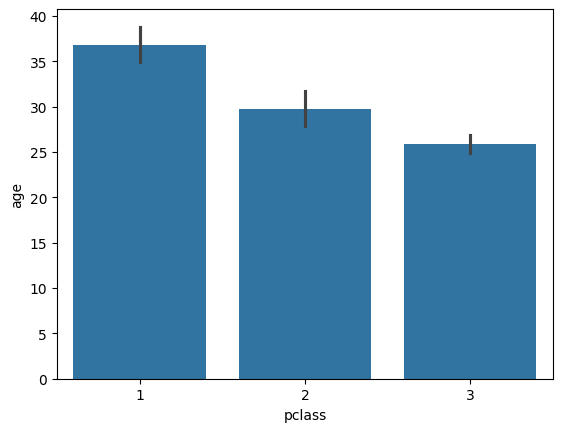

In [128]:
sns.barplot(x='pclass', y='age', data=df)

In [131]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
model = ols('age ~ pclass * pclass', data=df).fit()
anova_table = sm.stats.anova_lm(model, type=2)
anova_table

,df,sum_sq,mean_sq,F,PR(>F)
pclass,1.0,17429.695048,17429.695048,116.122704,1.558883e-25
Residual,889.0,133436.428421,150.097220,NaN,NaN


In [135]:
tuckey = pairwise_tukeyhsd(df['age'], groups=df['pclass']* df['who'], alpha=0.05)
tuckey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
child,childchild,-3.2763,0.9988,-17.8994,11.3468,False
child,childchildchild,-1.0024,1.0,-14.3937,12.3889,False
child,man,32.0245,0.0,18.959,45.0901,True
child,manman,25.2608,0.0,12.1321,38.3895,True
child,manmanman,20.8822,0.0,8.0148,33.7496,True
child,woman,26.9382,0.0,13.7766,40.0999,True
child,womanwoman,24.233,0.0,10.9181,37.548,True
child,womanwomanwoman,20.0879,0.0001,7.0086,33.1672,True
childchild,childchildchild,2.2739,0.995,-5.9803,10.5281,False
childchild,man,35.3009,0.0,27.5863,43.0154,True


<Axes: >

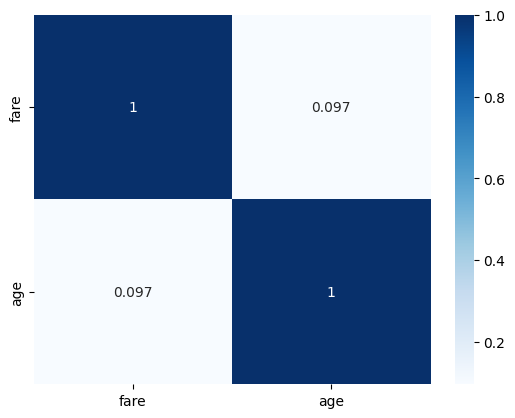

In [141]:
sns.heatmap(df[['fare', 'age']].corr(), annot=True, cmap='Blues')

<Axes: xlabel='total_bill', ylabel='tip'>

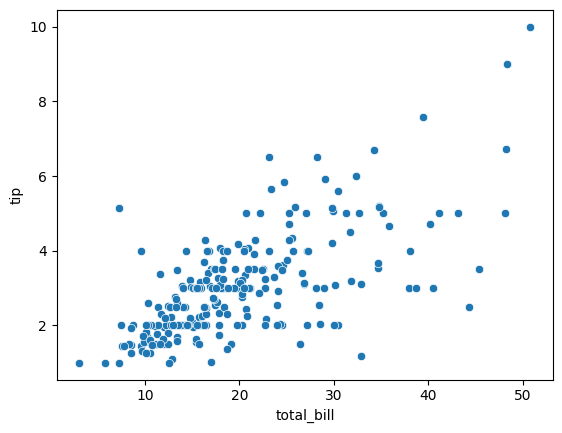

In [144]:
data = sns.load_dataset('tips')
sns.scatterplot(x='total_bill', y='tip', data=data)

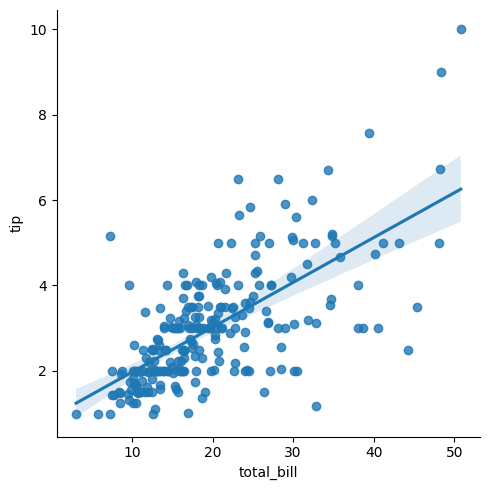

In [145]:
sns.lmplot(x='total_bill', y='tip', data=data)

In [148]:
data['total_bill'].corr(data['tip'])

np.float64(0.6757341092113645)

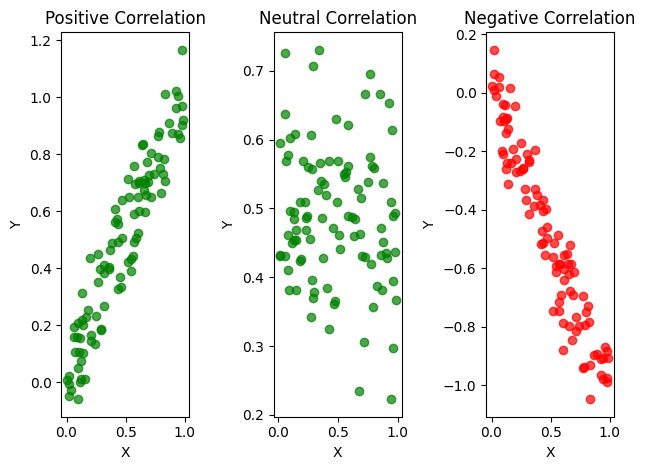

In [160]:
np.random.seed(0)
# Generate synthetic data
# Positive correlation
x = np.random.rand(100)
y_pos = x + np.random.normal(0, 0.1, 100)
# Neutral correlation
x_neutral = np.random.rand(100)
y_neutral = np.random.normal(0.5, 0.1, 100)
# Negative correlation
y_neg = -x + np.random.normal(0, 0.1, 100)
plt.subplot(1, 3, 1)
plt.scatter(x, y_pos, alpha=0.7, color='green')
# sns.lmplot(x= 'total_bill', y='tip', data=tips)
plt.title('Positive Correlation')
plt.xlabel('X')
plt.ylabel('Y')
# Negative Correlation
plt.subplot(1, 3, 2)
plt.scatter(x_neutral, y_neutral, alpha=0.7, color='green')
# sns.lmplot(x= 'total_bill', y='tip', data=tips)
plt.title('Neutral Correlation')
plt.xlabel('X')
plt.ylabel('Y')
# Negative Correlation
plt.subplot(1, 3, 3)
plt.scatter(x, y_neg, alpha=0.7, color='red')
plt.title('Negative Correlation')
plt.xlabel('X')
plt.ylabel('Y')
plt.tight_layout()
plt.show()